# Beat Timer v0.5 Evaluator

This notebook runs the audio-only predictor and then evaluates its output against an `.osu` map.

The `.osu` file is loaded only after prediction is complete. Its objects score grid accuracy; its red timing points measure agreement with the mapper's chosen segmentation.

Keep this notebook in the same directory as:

- `beattimer_core.py`
- `beattimer_evaluation.py`
- the MP3
- the `.osu` file

In [1]:
from pathlib import Path
import numpy as np
import importlib
import json

import beattimer_core as core
import beattimer_evaluation as evaluation_tools

In [2]:
# Reload after editing either module.
importlib.reload(core)
importlib.reload(evaluation_tools)

<module 'beattimer_evaluation' from 'c:\\Users\\Caue\\Desktop\\School\\Programming\\osu beattimer projec\\beattimer_evaluation.py'>

In [3]:
from pathlib import Path
import importlib.util
import sys

CORE_PATH = Path(
    "beattimer_core.py"
).resolve()

spec = importlib.util.spec_from_file_location(
    "beattimer_core",
    CORE_PATH,
)

if spec is None or spec.loader is None:
    raise ImportError(
        f"Could not load {CORE_PATH}"
    )

core = importlib.util.module_from_spec(spec)
sys.modules["beattimer_core"] = core
spec.loader.exec_module(core)

print("Loaded:", core.__file__)

Loaded: C:\Users\Caue\Desktop\School\Programming\osu beattimer projec\beattimer_core.py


## Inputs

In [4]:
song_selection = "reign_of_fear"

AUDIO_PATH = Path(Path("songs") / song_selection / "song.mp3")
OSU_PATH = Path(Path("songs") / song_selection / "song.osu")

ANALYSIS_SETTINGS = {
    "round_initial_bpm": 1,
    "use_local_tempo": True,
    "integer_section_bpm": True,
    "section_tolerance_ms": 6.0,
}

OBJECT_SUBDIVISIONS = (1, 2, 3, 4)
REDLINE_TIME_TOLERANCE_SECONDS = 0.300
DIAGNOSTIC_SHIFT_RANGE_MS = (-100.0, 100.0)
DIAGNOSTIC_SHIFT_STEP_MS = 0.5

## 1. Produce the MP3-only prediction

In [5]:
result = core.analyze_song(
    AUDIO_PATH,
    **ANALYSIS_SETTINGS,
)

core.print_analysis_summary(result)

File: songs\reign_of_fear\song.mp3
Duration: 389.956 s
Sample rate: 44100 Hz
Hop length: 256 samples
Raw global BPM: 182.419891
Used global BPM: 182.4
Analysis mode: local tempo
Detected onset candidates: 1044
Global-grid matched observations: 393
Global-grid median error: 26.712 ms
Global-grid 95% error: 56.005 ms
Dense offset windows: 1545
Dense offset p95 absolute: 184.274 ms
Dense offset global slope: +0.6169 ms/s
Dense local segments: 0 accepted / 1 total
Local windows: 1553
Trusted local windows: 732
Timing sections: 41
  1: 0.000s–78.750s, BPM=182.4, windows=0, matches=0, 95%=nanms
  2: 78.750s–82.375s, BPM=181.7, windows=4, matches=5, 95%=12.235ms
  3: 82.375s–85.375s, BPM=166.8, windows=3, matches=3, 95%=19.932ms
  4: 85.375s–93.875s, BPM=182.0, windows=14, matches=19, 95%=9.975ms
  5: 93.875s–98.125s, BPM=183.6, windows=9, matches=8, 95%=24.205ms
  6: 98.125s–98.875s, BPM=190.4, windows=3, matches=2, 95%=1.574ms
  7: 98.875s–100.625s, BPM=194.3, windows=7, matches=5, 95%=2.07

## 2. Evaluate after prediction

In [6]:
evaluation = evaluation_tools.evaluate_against_osu(
    result,
    OSU_PATH,
    subdivisions=OBJECT_SUBDIVISIONS,
    redline_time_tolerance=REDLINE_TIME_TOLERANCE_SECONDS,
    shift_range_ms=DIAGNOSTIC_SHIFT_RANGE_MS,
    shift_step_ms=DIAGNOSTIC_SHIFT_STEP_MS,
)

evaluation_tools.print_evaluation_summary(evaluation)

.osu file: songs\reign_of_fear\song.osu
Hit objects: 1587
Mapped redlines: 18
Objects scored: 1587 / 1587

Raw median object error: 20.286 ms
Diagnostic global shift: -20.000 ms
Aligned median object error: 1.657 ms
Aligned p95 object error: 10.370 ms

Objects within  2 ms:  55.2%
Objects within  5 ms:  77.8%
Objects within 10 ms:  94.3%
Objects within 20 ms:  98.5%
Objects within 40 ms:  99.8%

Initial anchor absolute time error: 118.158 ms; BPM error: +106.400
Boundary precision / recall / F1: 0.050 / 0.118 / 0.070


## 3. Plots

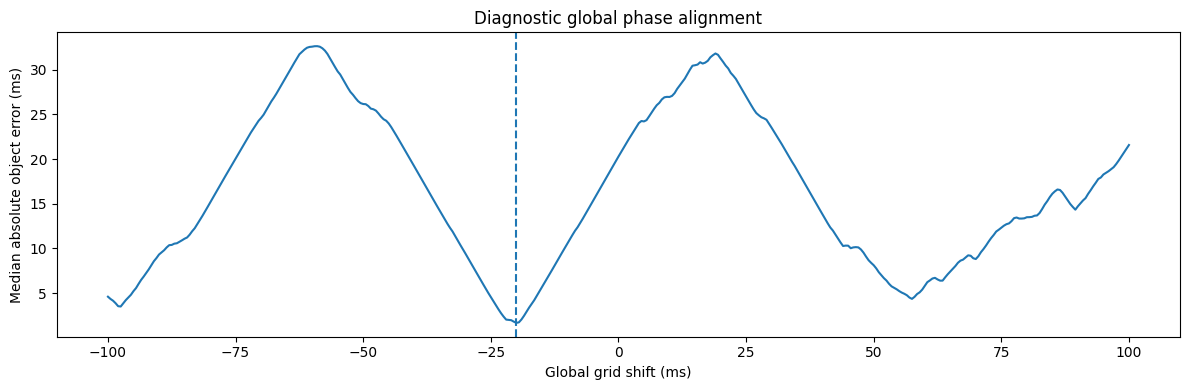

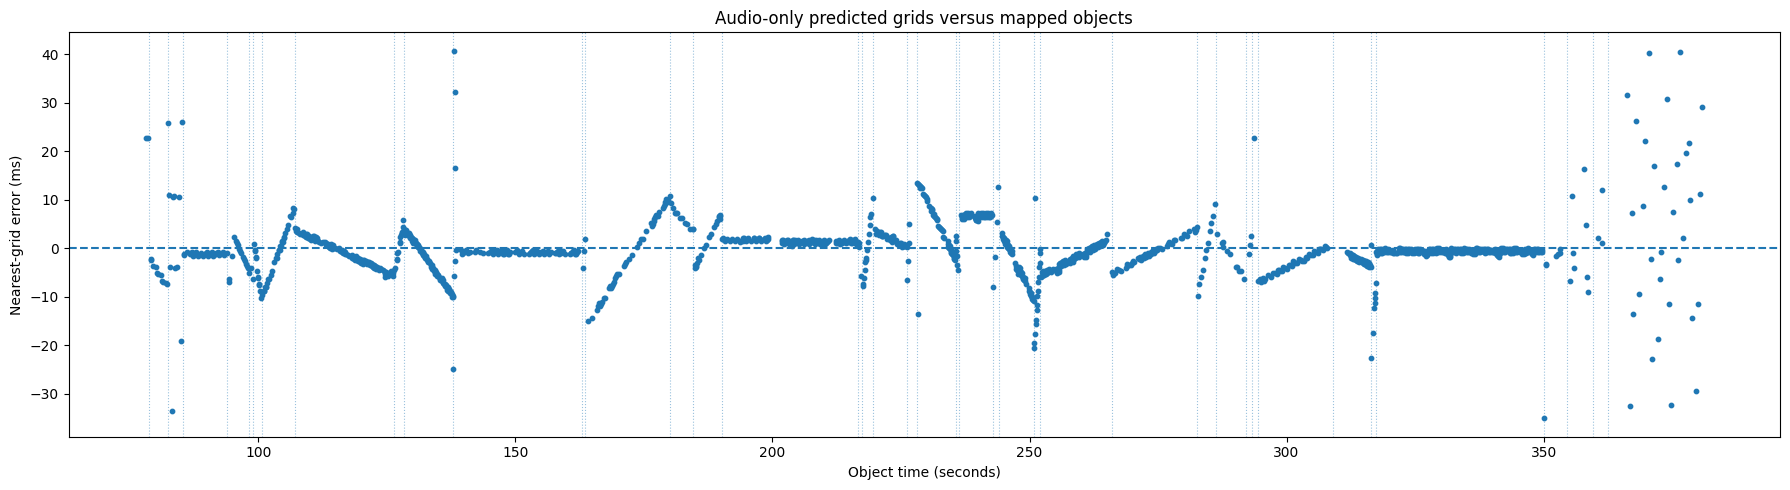

In [7]:
evaluation_tools.plot_evaluation(evaluation)

## 4. Per-section diagnostics

In [8]:
evaluation_tools.print_section_diagnostics(evaluation)

Section  0 |   0.00– 78.75s | 182.400 BPM | n=  2 | median= 22.79 ms | p95= 22.81 ms | slope=  +0.16 ms/s | insufficient evidence
Section  1 |  78.75– 82.38s | 181.700 BPM | n= 11 | median=  5.21 ms | p95=  7.23 ms | slope=  -1.68 ms/s | good
Section  2 |  82.38– 85.38s | 166.800 BPM | n= 11 | median= 10.85 ms | p95= 29.77 ms | slope=  -0.59 ms/s | acceptable
Section  3 |  85.38– 93.88s | 182.000 BPM | n= 31 | median=  1.05 ms | p95=  1.53 ms | slope=  +0.01 ms/s | good
Section  4 |  93.88– 98.12s | 183.600 BPM | n= 16 | median=  1.93 ms | p95=  6.50 ms | slope=  +0.11 ms/s | good
Section  5 |  98.12– 98.88s | 190.400 BPM | n=  2 | median=  4.58 ms | p95=  4.98 ms | slope=  +2.77 ms/s | insufficient evidence
Section  6 |  98.88–100.62s | 194.300 BPM | n= 13 | median=  5.89 ms | p95=  9.45 ms | slope=  -5.91 ms/s | acceptable
Section  7 | 100.62–107.12s | 202.600 BPM | n= 33 | median=  4.62 ms | p95=  8.83 ms | slope=  +2.93 ms/s | good
Section  8 | 107.12–126.38s | 201.900 BPM | n=113 

## 5. Optional prediction visualizer

In [9]:
figure = core.visualize_timing_segments(result)

## 6. Save a compact JSON benchmark

In [10]:
benchmark = {
    "audio_file": str(AUDIO_PATH),
    "osu_file": str(OSU_PATH),
    "global_bpm_raw": float(result["bpm_result"]["bpm"]),
    "global_bpm_used": float(result["initial_bpm"]),
    "timing_section_count": len(result["sections"]),
    "diagnostic_shift_ms": float(
        evaluation["shift_result"]["best_shift_ms"]
    ),
    "object_summary": evaluation["object_summary"],
    "redline_metrics": {
        key: evaluation["boundary_comparison"][key]
        for key in (
            "true_positives",
            "false_positives",
            "false_negatives",
            "precision",
            "recall",
            "f1",
        )
    },
}

OUTPUT_PATH = Path("benchmark_dump\\benchmark_v0.5.json")
OUTPUT_PATH.parent.mkdir(parents=True, exist_ok=True)

OUTPUT_PATH.write_text(
    json.dumps(benchmark, indent=2),
    encoding="utf-8",
)

print(f"Saved: {OUTPUT_PATH.resolve()}")

Saved: C:\Users\Caue\Desktop\School\Programming\osu beattimer projec\benchmark_dump\benchmark_v0.5.json


In [11]:
dense_figure = core.visualize_dense_offset_trajectory(
    result,
    minimum_confidence=0.20,
)

In [ ]:
print(
    "Dense segments:",
    len(result["dense_offset_segments"]),
)

accepted = [
    segment
    for segment in result["dense_offset_segments"]
    if segment["accepted"]
]

rejected = [
    segment
    for segment in result["dense_offset_segments"]
    if not segment["accepted"]
]

print("Accepted:", len(accepted))
print("Rejected:", len(rejected))

for index, segment in enumerate(
    accepted[:20],
    start=1,
):
    print(
        f"{index:2d} | "
        f"{segment['start_time']:7.2f}"
        f"–{segment['end_time']:7.2f}s | "
        f"slope="
        f"{segment['slope_ms_per_second']:+6.3f} ms/s | "
        f"p95="
        f"{segment['p95_absolute_residual_ms']:5.2f} ms | "
        f"coverage="
        f"{segment['confidence_coverage']:.2f}"
    )

core.visualize_segmented_dense_offset_trajectory(
    result
)

Dense segments: 1
Accepted: 0
Rejected: 1


In [13]:
segments = result["dense_offset_segments"]

print("Total:", len(segments))
print(
    "Accepted:",
    sum(segment["accepted"] for segment in segments),
)

for index, segment in enumerate(segments[:30]):
    print(
        f"{index:3d} | "
        f"{segment['start_time']:7.2f}"
        f"–{segment['end_time']:7.2f}s | "
        f"accepted={segment['accepted']} | "
        f"windows={segment['window_count']} | "
        f"coverage={segment['confidence_coverage']:.3f}"
    )

Total: 1
Accepted: 0
  0 |    2.00– 387.98s | accepted=False | windows=1545 | coverage=1.000
